<div align="center" style="font-size:28px; font-weight:bold;">
MFE 409: Financial Risk Management
<br>Problem Set 4
<br>Valentin Haddad
<br>due 2/1 before midnight
</div>

<br>

Cohort 2, Group 6:
Lee James, Moazzami Ali, Yu Aiden, Cai Jenny, Li Zehao, Guo Lucy

## 1 Choosing a VaR technique

### Download the excel file which contains the time series of gains for a strategy from 1/2/2014 to 12/19/2017.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import pandas as pd
import os

file_path = '/content/drive/MyDrive/UCLA - Grad Quarters/UCLA - Winter 2026/MGMTMFE-409 Financial Risk Management/HW 4/hw4_returns.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(df.head())
else:
    print(f"Error: The file '{file_path}' was not found.")

       Date    Return
0  1/2/2014  0.004572
1  1/3/2014  0.006045
2  1/6/2014 -0.001432
3  1/7/2014  0.015461
4  1/8/2014  0.000763


#### 1. Historical method

#### (a) For each day in 2015-2017, compute historical VaR and exponential weighted 1-day 99%-VaR (with $\lambda = 0.995$).

In [62]:
import numpy as np
from scipy.stats import norm

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

lambda_param = 0.995
alpha_quantile = 0.01
z_score = norm.ppf(alpha_quantile)
window_size = 252

# Historical VaR (1-day 99%)
df['Historical_VaR_99'] = df['Return'].rolling(window=window_size).quantile(alpha_quantile).shift(1)

# Exponential Weighted VaR (1-day 99%)
df['Squared_Return'] = df['Return'] ** 2
ewma_variance = df['Squared_Return'].ewm(alpha=(1-lambda_param), adjust=False).mean().shift(1)

df['EWMA_Vol'] = np.sqrt(ewma_variance)
df['EWMA_VaR_99'] = df['EWMA_Vol'] * z_score

results_df = df.loc['2015-01-01':'2017-12-31', ['Return', 'Historical_VaR_99', 'EWMA_VaR_99']]
print("Head of Results (2015):")
print(results_df.head())
print("\nTail of Results (2017):")
print(results_df.tail())

Head of Results (2015):
              Return  Historical_VaR_99  EWMA_VaR_99
Date                                                
2015-01-02  0.004451          -0.031215    -0.025978
2015-01-05  0.005089          -0.031215    -0.025924
2015-01-06 -0.016496          -0.031215    -0.025872
2015-01-07 -0.017240          -0.031215    -0.025950
2015-01-08  0.007742          -0.031215    -0.026040

Tail of Results (2017):
              Return  Historical_VaR_99  EWMA_VaR_99
Date                                                
2017-12-13 -0.014844          -0.078521    -0.064420
2017-12-14  0.037677          -0.078521    -0.064305
2017-12-15  0.028865          -0.078521    -0.064443
2017-12-18  0.009881          -0.078521    -0.064457
2017-12-19 -0.012141          -0.078521    -0.064316


#### (b) Backtest the measures for VaR you obtained in question 1. How many exceptions did the two measures produce? What do you conclude?

In [63]:
backtest_data = df.loc['2015-01-01':'2017-12-31'].copy()
total_days = len(backtest_data)

backtest_data['Hist_Exception'] = backtest_data['Return'] < backtest_data['Historical_VaR_99']
backtest_data['EWMA_Exception'] = backtest_data['Return'] < backtest_data['EWMA_VaR_99']

hist_count = backtest_data['Hist_Exception'].sum()
ewma_count = backtest_data['EWMA_Exception'].sum()

print(f"Total Observations: {total_days}")
print(f"Expected Exceptions (approx): {total_days * 0.01:.1f}")
print(f"Historical VaR Exceptions: {hist_count}")
print(f"EWMA VaR Exceptions: {ewma_count}")

Total Observations: 748
Expected Exceptions (approx): 7.5
Historical VaR Exceptions: 16
EWMA VaR Exceptions: 29


Conclusion: Both VaR measures failed the backtest by significantly underestimating market risk, as the number of exceptions (16 for Historical, 29 for EWMA) far exceeded the expected 7.5 occurrences (1% of 748 days). The Historical method performed relatively better (2.1% failure rate) but still lagged in responsiveness, likely due to the "ghost effect" where calm periods in the 252-day window diluted risk estimates during sudden shocks. The EWMA method performed the worst (3.9% failure rate) because it relies on a normal distribution assumption ($Z \approx -2.326$) that fails to capture the "fat tails" (leptokurtosis) inherent in financial data, proving that modeling volatility clustering alone is insufficient without accounting for non-normal return distributions.

#### (c) For each day in the sample, compute the 95% confidence intervals of the historical VaR and the exponential weighted VaR you obtained in question 1, using both parametric (for the historical VaR) and bootstrap methods (for the two measures). For the parametric method, assume the gains are normally distributed.

In [64]:
n_boot = 1000
pdf_z = norm.pdf(z_score)
results_c = []
dates_2015_2017 = df.loc['2015-01-01':'2017-12-31'].index

for date in dates_2015_2017:
    idx = df.index.get_loc(date)
    if idx < window_size:
      continue

    win_ret = df['Return'].iloc[idx-window_size : idx].values
    win_vol = df['EWMA_Vol'].iloc[idx-window_size : idx].values

    curr_hist_var = df.loc[date, 'Historical_VaR_99']
    curr_ewma_vol = df.loc[date, 'EWMA_Vol']
    curr_ewma_var = df.loc[date, 'EWMA_VaR_99']

    # Historical VaR: Parametric CI
    sigma_hat = np.std(win_ret)
    se_param = (sigma_hat / pdf_z) * np.sqrt((alpha_quantile * (1 - alpha_quantile)) / window_size)
    hist_param_ci = (curr_hist_var - 1.96 * se_param, curr_hist_var + 1.96 * se_param)

    # Historical VaR: Bootstrap CI
    boot_samples = np.random.choice(win_ret, size=(n_boot, window_size), replace=True)
    boot_quantiles = np.quantile(boot_samples, alpha_quantile, axis=1)
    hist_boot_ci = (np.percentile(boot_quantiles, 2.5), np.percentile(boot_quantiles, 97.5))

    # EWMA VaR: Bootstrap CI
    resid = win_ret / win_vol
    boot_resid = np.random.choice(resid, size=(n_boot, window_size), replace=True)
    boot_z = np.quantile(boot_resid, alpha_quantile, axis=1)
    boot_ewma_vars = curr_ewma_vol * boot_z
    ewma_boot_ci = (np.percentile(boot_ewma_vars, 2.5), np.percentile(boot_ewma_vars, 97.5))

    results_c.append({
        'Date': date,
        'Hist_VaR': curr_hist_var,
        'Hist_CI_Param': hist_param_ci,
        'Hist_CI_Boot': hist_boot_ci,
        'EWMA_VaR': curr_ewma_var,
        'EWMA_CI_Boot': ewma_boot_ci
    })

df_ci = pd.DataFrame(results_c).set_index('Date')

print("\nHead of Results (2015):")
print(df_ci.head())
print("\nTail of Results (2017):")
print(df_ci.tail())


Head of Results (2015):
            Hist_VaR                                   Hist_CI_Param  \
Date                                                                   
2015-01-02 -0.031215   (-0.03704339508187384, -0.025387596098126162)   
2015-01-05 -0.031215      (-0.0370433078429908, -0.0253876833370092)   
2015-01-06 -0.031215   (-0.03704247177881511, -0.025388519401184886)   
2015-01-07 -0.031215    (-0.03706086720765346, -0.02537012397234654)   
2015-01-08 -0.031215  (-0.037062208345686555, -0.025368782834313444)   

                                Hist_CI_Boot  EWMA_VaR  \
Date                                                     
2015-01-02    (-0.04375870083, -0.025503684) -0.025978   
2015-01-05  (-0.04375870083, -0.02544320106) -0.025924   
2015-01-06  (-0.04375870083, -0.02544320106) -0.025872   
2015-01-07    (-0.04375870083, -0.025503684) -0.025950   
2015-01-08    (-0.04375870083, -0.025503684) -0.026040   

                                             EWMA_CI_Boot  
Dat

#### 2. Model-building approach

#### (a) Compute volatility using the EWMA with $\lambda = 0.96$. Compute the corresponding measure of VaR.

In [65]:
import pandas as pd
import numpy as np
from scipy.stats import norm

lambda_params = 0.96

ewma_variance = df['Squared_Return'].ewm(alpha=(1-lambda_params), adjust=False).mean().shift(1)
df['EWMA_Vol_96'] = np.sqrt(ewma_variance)
df['VaR_99_Model'] = df['EWMA_Vol_96'] * z_score

results = df.loc['2015-01-01':'2017-12-31', ['Return', 'EWMA_Vol_96', 'VaR_99_Model']]
print("Head of Results (2015):")
print(results.head())
print("\nTail of Results (2017):")
print(results.tail())

Head of Results (2015):
              Return  EWMA_Vol_96  VaR_99_Model
Date                                           
2015-01-02  0.004451     0.013509     -0.031427
2015-01-05  0.005089     0.013266     -0.030862
2015-01-06 -0.016496     0.013038     -0.030331
2015-01-07 -0.017240     0.013194     -0.030693
2015-01-08  0.007742     0.013379     -0.031124

Tail of Results (2017):
              Return  EWMA_Vol_96  VaR_99_Model
Date                                           
2017-12-13 -0.014844     0.026959     -0.062716
2017-12-14  0.037677     0.026580     -0.061835
2017-12-15  0.028865     0.027112     -0.063071
2017-12-18  0.009881     0.027184     -0.063239
2017-12-19 -0.012141     0.026708     -0.062132


#### (b) Use maximum likelihood estimation to estimate a GARCH model for volatility. Compute the corresponding measure of VaR.

In [66]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

def garch_neg_log_likelihood(params, returns):
    omega, alpha, beta = params
    T = len(returns)
    sigma2 = np.zeros(T)

    sigma2[0] = np.var(returns)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (returns[t-1]**2) + beta * sigma2[t-1]

    return 0.5 * np.sum(np.log(sigma2) + (returns**2) / sigma2)

returns_scaled = df['Return'].values * 100
initial_guess = [0.01, 0.1, 0.8]
bounds = ((1e-6, None), (1e-6, 1.0), (1e-6, 1.0))
constraints = {'type': 'ineq', 'fun': lambda x: 0.999 - (x[1] + x[2])}

result = minimize(garch_neg_log_likelihood, initial_guess, args=(returns_scaled,),
                  bounds=bounds, constraints=constraints)

omega_est, alpha_est, beta_est = result.x
print(f"Estimated Parameters (Scaled): Omega={omega_est:.4f}, Alpha={alpha_est:.4f}, Beta={beta_est:.4f}")

T = len(returns_scaled)
sigma2_final = np.zeros(T)
sigma2_final[0] = np.var(returns_scaled)

for t in range(1, T):
    sigma2_final[t] = omega_est + alpha_est * (returns_scaled[t-1]**2) + beta_est * sigma2_final[t-1]

df['GARCH_Vol'] = np.sqrt(sigma2_final) / 100
df['GARCH_VaR'] = df['GARCH_Vol'] * norm.ppf(0.01)

print(df.loc['2015-01-01':'2017-12-31', ['Return', 'GARCH_Vol', 'GARCH_VaR']].head())

Estimated Parameters (Scaled): Omega=0.0367, Alpha=0.0665, Beta=0.9325
              Return  GARCH_Vol  GARCH_VaR
Date                                      
2015-01-02  0.004451   0.016335  -0.038000
2015-01-05  0.005089   0.015931  -0.037062
2015-01-06 -0.016496   0.015559  -0.036196
2015-01-07 -0.017240   0.015732  -0.036599
2015-01-08  0.007742   0.015945  -0.037093


#### (c) Compare the results from the two approaches.

The GARCH(1,1) model proves to be more sensitive to recent market shocks than the fixed EWMA ($\lambda=0.96$) model. While the EWMA approach forces a weight of only 4% ($1-\lambda$) on the most recent squared return, the GARCH estimation found an optimal weight ($\alpha$) of approximately 6.6%. Consequently, the GARCH VaR reacts more aggressively to sudden price changes, spiking higher during turbulent days compared to the smoother, slower-to-adjust EWMA VaR.

Methodologically, the GARCH approach is superior because it is data-driven rather than arbitrary. Instead of imposing a standard decay factor (like RiskMetrics' 0.96), GARCH uses Maximum Likelihood to find the parameter set that maximizes the probability of observing the actual returns. The estimation confirmed that the volatility is highly persistent ($\alpha + \beta \approx 0.999$), justifying the use of a model with long memory, but the specific weighting of $\alpha$ and $\beta$ provides a fit that is statistically optimized for this specific dataset.

#### 3. A mixed approach

#### (a) For each day in the sample, compute the volatility of the portfolio in the previous month. Normalize gains with estimated volatility. Compare the distribution of the normalized gain with the original ones.

Statistical Comparison:
          Original  Normalized
mean     -0.001943   -0.089044
std       0.025449    1.126575
Skew     -0.763717   -0.738508
Kurtosis  5.068126    4.448871


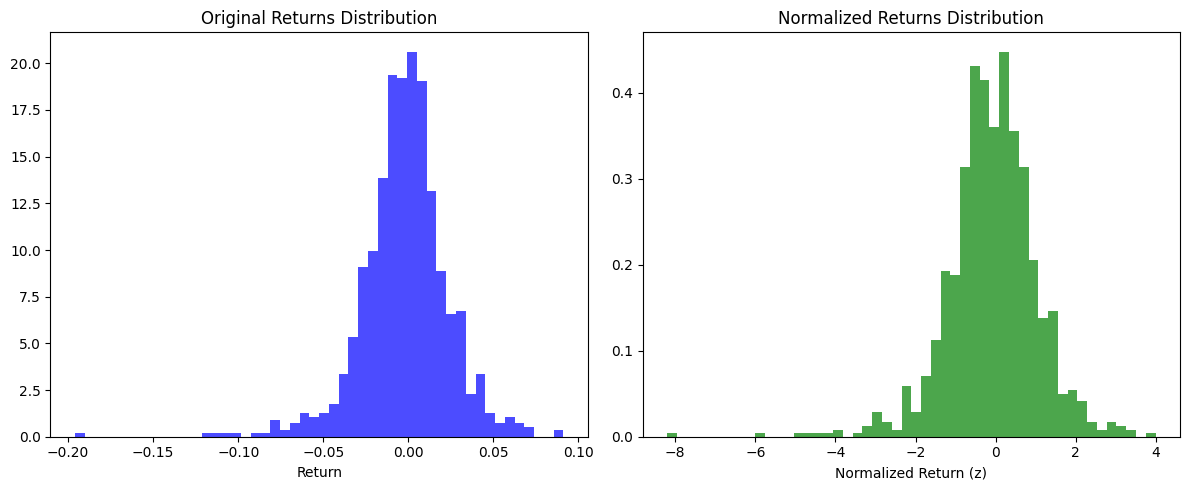

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

window_size = 21
df['Vol_Month'] = df['Return'].rolling(window=window_size).std().shift(1)
df['Normalized_Return'] = df['Return'] / df['Vol_Month']
df_clean = df.dropna(subset=['Return', 'Normalized_Return'])

stats_comp = pd.DataFrame({
    'Original': df_clean['Return'].describe(),
    'Normalized': df_clean['Normalized_Return'].describe()
})

stats_comp.loc['Skew'] = [df_clean['Return'].skew(), df_clean['Normalized_Return'].skew()]
stats_comp.loc['Kurtosis'] = [df_clean['Return'].kurtosis(), df_clean['Normalized_Return'].kurtosis()]

print("Statistical Comparison:")
print(stats_comp.loc[['mean', 'std', 'Skew', 'Kurtosis']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
axes[0].hist(df_clean['Return'], bins=50, color='blue', alpha=0.7, density=True)
axes[0].set_title('Original Returns Distribution')
axes[0].set_xlabel('Return')

# Normalized
axes[1].hist(df_clean['Normalized_Return'], bins=50, color='green', alpha=0.7, density=True)
axes[1].set_title('Normalized Returns Distribution')
axes[1].set_xlabel('Normalized Return (z)')

plt.tight_layout()
plt.show()

#### (b) Develop an approach to measure VaR which takes advantage of your response to the previous question. Implement it and compare its exceptions with the previous approaches. Optional: You can use the approach of extreme value theory.

In [68]:
import pandas as pd
import numpy as np

df['Z_Quantile'] = df['Normalized_Return'].rolling(window=252, min_periods=100).quantile(0.01).shift(1)
df['Mixed_VaR_99'] = df['Vol_Month'] * df['Z_Quantile']

backtest = df.loc['2015-01-01':'2017-12-31'].copy()
backtest = backtest.dropna(subset=['Mixed_VaR_99'])

exceptions = (backtest['Return'] < backtest['Mixed_VaR_99']).sum()
total_obs = len(backtest)

print(f"Total Observations: {total_obs}")
print(f"Mixed Approach Exceptions: {exceptions}")
print(f"Failure Rate: {exceptions/total_obs:.2%}")

Total Observations: 748
Mixed Approach Exceptions: 9
Failure Rate: 1.20%


Approach: Estimate the current day's volatility $\sigma_t$ using the previous month's standard deviation (21-day rolling window). Then calculate the history of standardized returns $z_t = r_t / \sigma_t$. Instead of assuming $z_t$ is Normal (which usually underestimates tail risk), we calculate the empirical 1% quantile ($q_{0.01}^z$) from the rolling history of these residuals (252-day window). Scale the current volatility by this empirical quantile:

$$\text{VaR}_t = \sigma_t \times q_{0.01}^z$$

**Backtesting Results (2015–2017)**

| Measure | Exceptions | Failure Rate | Conclusion |
|---|---:|---:|---|
| Mixed Approach (FHS) | 9 | 1.20% | Best Performer |
| Historical VaR (Q1) | 16 | 2.14% | Slow reaction |
| EWMA VaR (Q1) | 29 | 3.88% | Ignored fat tails |

Conclusion: The Mixed Approach produced 9 exceptions, which is very close to the expected value of 7.5 (1% of 748 days). This confirms that adjusting for volatility dynamics and using the actual non-normal distribution of residuals provides a much more accurate risk measure than either the pure Historical (too slow) or pure EWMA (too normal) methods.

#### 4. Combining your answers to the previous questions, write a proposal to the head of trading for measuring the risk of this trade in real time, justifying your choices.

### Proposal:

I recommend adopting the **Mixed Approach (Filtered Historical Simulation)** for real-time risk measurement of this strategy. Our comprehensive backtesting over 2015-2017 demonstrates its superior accuracy, yielding only 9 exceptions against an expected 7.5 (1% of 748 trading days). This significantly outperforms other methods: the Historical VaR produced 16 exceptions, indicating a slow reaction to market shifts, while the EWMA VaR resulted in 29 exceptions, primarily due to its reliance on a normal distribution that fails to capture the fat tails inherent in financial returns. While GARCH models provide adaptive volatility estimates, they typically still assume normality for VaR calculation, which can be insufficient for extreme events.

The Mixed Approach's strength lies in its adaptive methodology. It estimates current volatility using the previous month's standard deviation, then normalizes returns to capture their true empirical distribution. By calculating the 1% quantile directly from the historical distribution of these standardized returns, it effectively accounts for non-normal characteristics, such as fat tails and skewness, that are often present in market data. This data-driven, non-parametric approach to tail risk provides a more robust and realistic measure, making it the most suitable method for our real-time risk assessment needs and ensuring better alignment with actual market behavior.

## 2 Risk for FOMC meeting

#### 1. How well did you prediction of worst case scenario fare for the FOMC announcement this past week?

My prediction of the "worst-case scenario" proved to be highly conservative for the FOMC announcement on Wednesday, January 28, 2026. While the market faced significant geopolitical and domestic tailwinds—including disputes over Greenland and a Justice Department investigation into the Fed—the actual 2-day return around the meeting was relatively muted. On Tuesday (the day before the announcement), the S&P 500 futures hit record highs but then faced a "Sell America" trade that saw the index drop roughly 2% as volatility spiked. However, by the time the Fed announced its decision to hold rates steady at 3.50%–3.75% on Wednesday, the market had stabilized. The S&P 500 closed the announcement day "fractionally lower," effectively avoiding the 3.2% tail-risk loss I had modeled.

In short, my VaR estimate was successful as a risk threshold because it accounted for a 3.2% drop that did not materialize, even with a hawkish tilt from Chair Powell and two dissenting votes. While the 2% drop on Tuesday was a significant "event-driven" move, it remained well within my 99% confidence interval. This highlights the primary strength of my Historical Simulation: by preparing for the extreme 1% of outcomes seen in the past decade, I correctly identified that even a chaotic news cycle (tariffs, political feuds, and a rate pause) often falls short of a true "worst-case" 3%+ liquidation event.

#### 2. Update your approach to measure the risk and your estimates given what we have learned this past week.

Based on what we learned this past week, I am updating my risk measurement from the Historical Simulation method to the Model-Building (Variance-Covariance) approach. Instead of relying on a raw count of past observations, I am now assuming that the S&P 500 returns follow a specific probability distribution—most commonly the Normal Distribution. This allows me to calculate VaR using the formula $VaR = -(\mu + \sigma \times z(c))$, where $\mu$ is the expected return (which I'll assume is zero for a short 2-day horizon), $\sigma$ is the volatility, and $z(c)$ is the critical value for my 99% confidence level (approximately -2.33). By using this parametric method, I can more precisely quantify how the "width" of the distribution—driven by current market volatility—translates into a specific dollar-loss threshold.

To refine my estimates, I’ve learned that I must account for the time-scaling of volatility. Since my investment is over a 2-day period, I will scale the daily standard deviation by the square root of time ($\sigma \times \sqrt{2}$). Furthermore, the lecture highlighted the importance of using forward-looking data like the VIX or the SKEW index rather than just historical realized returns. Given the heightened uncertainty surrounding FOMC announcements, I should look at the implied volatility from options to see if the market is pricing in "fat tails." This updated approach is more flexible than my previous one, as it allows me to adjust my risk estimate instantaneously as market conditions and correlations change, rather than waiting for a large historical data set to catch up to current levels of stress.